# Exercise 3

## Imports

In [83]:
import math
import os
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydub import AudioSegment
from scipy import stats
from scipy.io import arff

## Constants

In [84]:
current_dir = Path.cwd()

# Music file
classical_audiofile_path = current_dir.joinpath("data", "classical.mp3")

# Features
features_folder_path = current_dir.joinpath("data", "features")

# Audio chunks output
audio_chunks_output_path = current_dir.joinpath("data", "outputs", "audio_chunks")

## Exercise 1

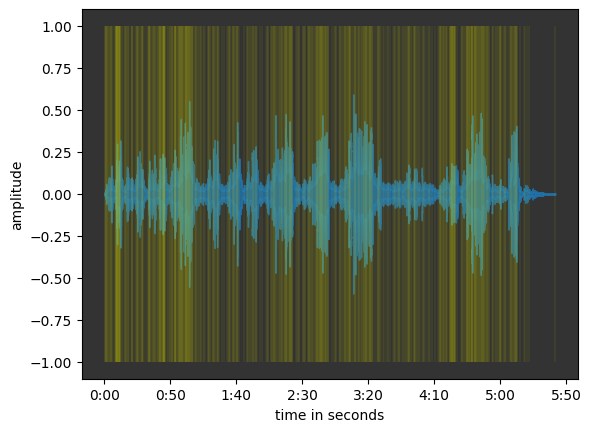

In [85]:
y, sr = librosa.load(classical_audiofile_path)
duration_sec = len(y) / sr
duration_ms = duration_sec * 1000

onsets = librosa.onset.onset_detect(y=y, sr=sr)
onset_times = librosa.frames_to_time(onsets, sr=sr)

# plot everything
plt.figure()
ax = plt.subplot(1, 1, 1)
ax.set_facecolor("#333333")

librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.8)

ax.vlines(onset_times, -1, 1, linestyle="-", alpha=0.05, color="yellow")
ax.set_xlabel("time in seconds")
ax.set_ylabel("amplitude")

plt.show()

## Exercise 2

In [86]:
# SPLIT AUDIO INTO 5s CHUNKS
audio = AudioSegment.from_mp3(classical_audiofile_path)

chunk_seconds = 5
chunk_length_ms = chunk_seconds * 1000

chunk_paths = []
chunk_onsets = []
for i in range(0, len(audio), chunk_length_ms):
    chunk_id = i // chunk_length_ms
    chunk = audio[i:i + chunk_length_ms]
    chunk_file_name = f"chunk_{chunk_id}.mp3"
    chunk_path = audio_chunks_output_path.joinpath(chunk_file_name)

    chunk.export(chunk_path, format="mp3")
    chunk_paths.append(chunk_path)

    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)

    # For ex2
    chunk_onsets.append(len(onsets))
    print(f"chunk {chunk_id} -> nº onsets = {len(onsets)}")

chunk 0 -> nº onsets = 13
chunk 1 -> nº onsets = 19
chunk 2 -> nº onsets = 28
chunk 3 -> nº onsets = 10
chunk 4 -> nº onsets = 12
chunk 5 -> nº onsets = 15
chunk 6 -> nº onsets = 11
chunk 7 -> nº onsets = 15
chunk 8 -> nº onsets = 19
chunk 9 -> nº onsets = 21
chunk 10 -> nº onsets = 19
chunk 11 -> nº onsets = 21
chunk 12 -> nº onsets = 25
chunk 13 -> nº onsets = 14
chunk 14 -> nº onsets = 13
chunk 15 -> nº onsets = 14
chunk 16 -> nº onsets = 16
chunk 17 -> nº onsets = 13
chunk 18 -> nº onsets = 15
chunk 19 -> nº onsets = 13
chunk 20 -> nº onsets = 13
chunk 21 -> nº onsets = 14
chunk 22 -> nº onsets = 17
chunk 23 -> nº onsets = 18
chunk 24 -> nº onsets = 17
chunk 25 -> nº onsets = 15
chunk 26 -> nº onsets = 19
chunk 27 -> nº onsets = 18
chunk 28 -> nº onsets = 18
chunk 29 -> nº onsets = 14
chunk 30 -> nº onsets = 14
chunk 31 -> nº onsets = 20
chunk 32 -> nº onsets = 22
chunk 33 -> nº onsets = 18
chunk 34 -> nº onsets = 18
chunk 35 -> nº onsets = 13
chunk 36 -> nº onsets = 19
chunk 37 ->

In [87]:
# READ FEATURES AND MERGE THEM BY CHUNKS
arff_files = sorted(
    [os.path.join(features_folder_path, f) for f in os.listdir(features_folder_path) if f.endswith(".arff")])

# Read features into df
dfs = []
for f in arff_files:
    data, meta = arff.loadarff(f)
    df = pd.DataFrame(data)
    df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)
    df = df.apply(pd.to_numeric, errors='coerce')
    df.set_index('WindowNumber', inplace=True)
    dfs.append(df)
features_df = pd.concat(dfs, axis=1)
print(features_df)

/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_56558/1244638929.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0                 0.025391          1828.1770 

In [88]:
num_windows = features_df.shape[0]
print(f"Number of feature windows: {num_windows}")
print(f"Duration of piece (ms): {duration_ms:.2f}")

windows_per_chunk = math.floor(num_windows / duration_ms * chunk_length_ms)
print(f"Windows per chunk aprox: {windows_per_chunk}")

# Merge by chunks
avg_features_per_chunk_df = (features_df
                             .groupby(np.arange(len(features_df)) // windows_per_chunk)
                             .mean(numeric_only=True)
                             .reset_index(names='chunk_id'))
print(avg_features_per_chunk_df)

Number of feature windows: 14720
Duration of piece (ms): 341812.24
Windows per chunk aprox: 215
    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.057999         919.275814                2.673341   
1          1            0.053661         660.858898                2.886185   
2          2            0.054615         746.061896                2.861431   
3          3            0.047838         626.281600                2.867888   
4          4            0.042851         585.785876                2.897262   
..       ...                 ...                ...                     ...   
64        64            0.026208         496.067564                2.770961   
65        65            0.022602         472.591414                2.637848   
66        66            0.017360         642.144981                2.171217   
67        67            0.015720        1605.367168                1.205941   
68        68            0.011016   

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


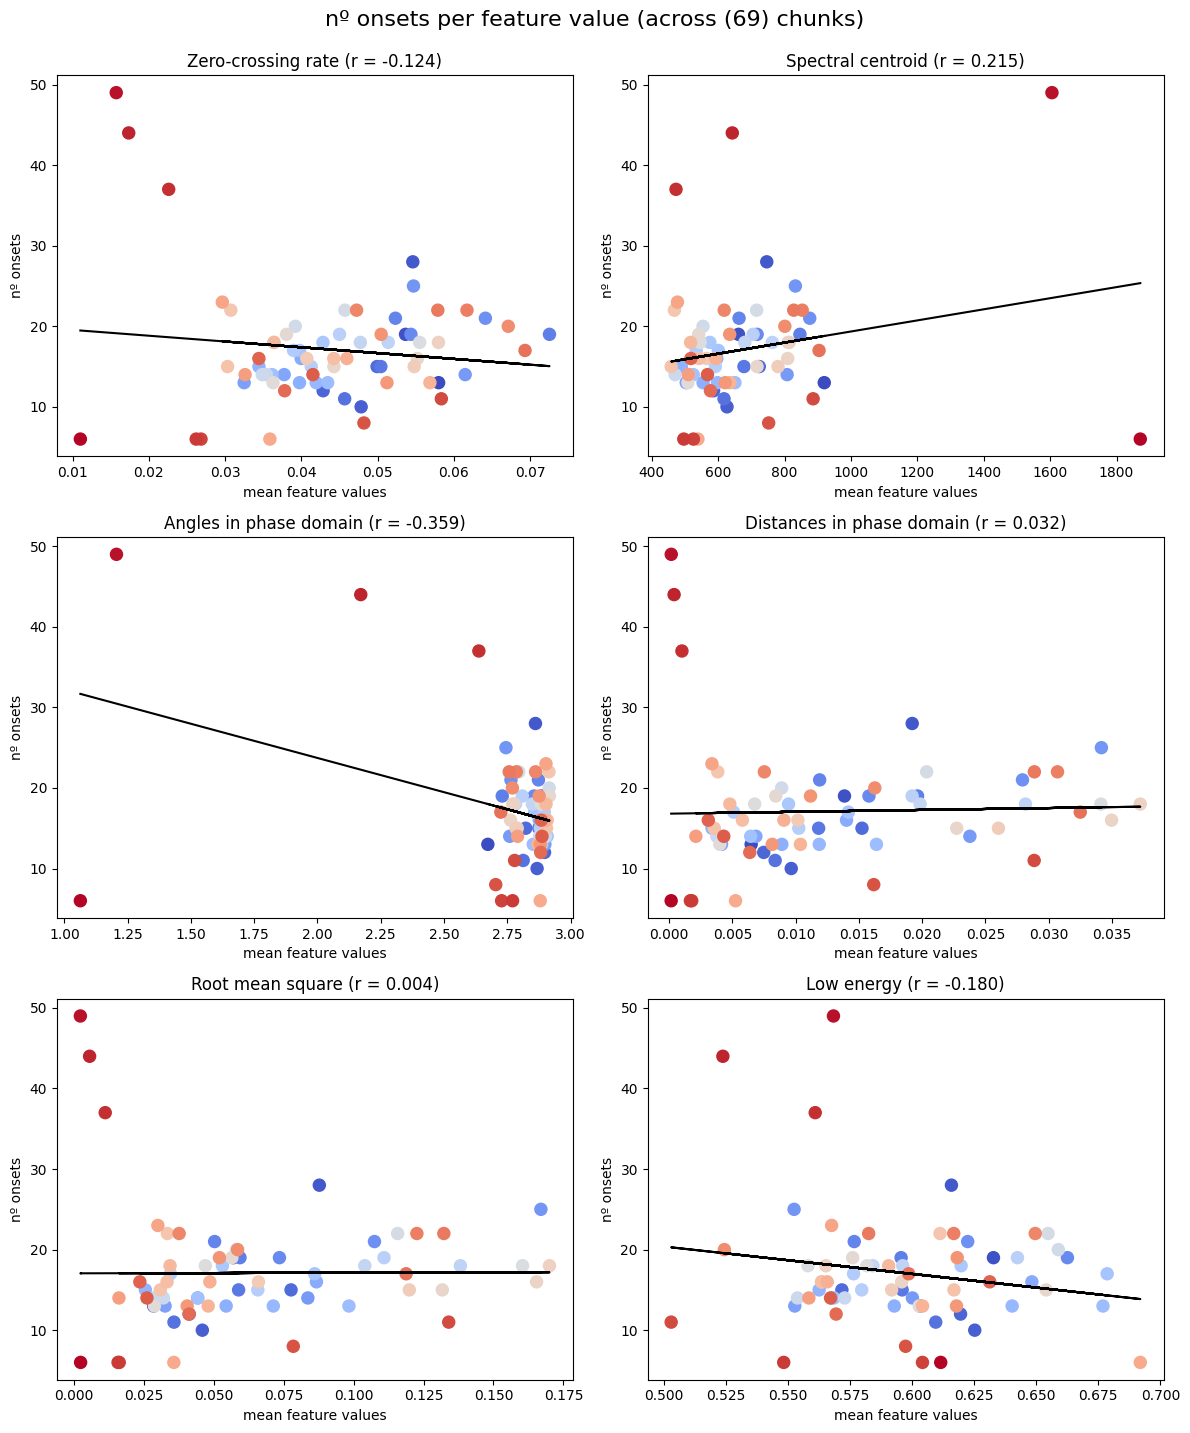

{'Zero-crossing rate': np.float64(-0.12397816312948268),
 'Spectral centroid': np.float64(0.21527725289771107),
 'Angles in phase domain': np.float64(-0.3588433592411896),
 'Distances in phase domain': np.float64(0.032230981689916095),
 'Root mean square': np.float64(0.004101743080444654),
 'Low energy': np.float64(-0.18027676533787818)}

In [89]:
# PLOT [nº ONSETS X avg FEATURE VALUE]

def plot_features(df: pd.DataFrame, title: str = "", regression_line: bool = False):
    regression_value_map = {}

    plt.figure(figsize=(12, 14))
    colors = np.arange(len(chunk_onsets))

    for f_idx, feature in enumerate(features_df.columns):
        print(f"Plotting for feature: {feature}")

        plt.subplot(3, 2, f_idx + 1)

        x = np.array(df[feature])
        y = np.array(chunk_onsets)
        plt.scatter(x, y, c=colors, cmap='coolwarm', marker='o', s=75)
        #plt.scatter(df[feature], chunk_onsets, c="blue", marker='o', s=75)

        # Regression Line
        if regression_line:
            slope, intercept, r, p, std_err = stats.linregress(x, y)
            plt.plot(x, slope * x + intercept, color="black", label=f"{r}")

            regression_value_map[feature] = r
            plt.title(f"{feature} (r = {r:.3f})")
        else:
            plt.title(f"{feature}")

        plt.xlabel("mean feature values")
        plt.ylabel("nº onsets")
        plt.tight_layout()

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

    return regression_value_map


plot_features(avg_features_per_chunk_df, title=f"nº onsets per feature value (across ({len(chunk_onsets)}) chunks)",
              regression_line=True)

## Exercise 3

In [90]:
onset_frames_mask = np.zeros(num_windows, dtype=bool)
non_onset_frames_mask = np.zeros(num_windows, dtype=bool)

ms_per_window = duration_ms / num_windows
print(f"Windows (ms): {ms_per_window:.2f}")


def get_window_id(onset_time_ms: float):
    return int(onset_time_ms // ms_per_window)


prev_window_id = None
for chunk_idx, chunk_path in enumerate(chunk_paths):
    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)
    onset_ms = librosa.frames_to_time(onsets, sr=sr)

    base_time_ms = chunk_idx * chunk_seconds * 1000
    for onset_idx, (onset, onset_ms) in enumerate(zip(onsets, onset_ms)):
        window_id = get_window_id(base_time_ms + onset_ms)

        onset_frames_mask[window_id] = True

        if prev_window_id is not None:
            middle_window_id = prev_window_id + ((window_id - prev_window_id) // 2)
            non_onset_frames_mask[middle_window_id] = True

        prev_window_id = window_id

Windows (ms): 23.22


In [91]:
onset_frames_df = (features_df
                   .groupby(np.arange(len(features_df)) // windows_per_chunk)
                   .apply(lambda g: g[onset_frames_mask[g.index.to_numpy(dtype=int) - 1]].mean(numeric_only=True))
                   .reset_index(drop=True)
                   .reset_index(names='chunk_id'))
print(onset_frames_df)

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.000000          -1.000000                0.000000   
1          1            0.035156         553.804100                2.915847   
2          2            0.076172        1083.786600                2.738030   
3          3            0.032227         455.243195                2.943768   
4          4            0.050781         610.126400                2.897755   
..       ...                 ...                ...                     ...   
64        64            0.025391         483.665860                2.845931   
65        65            0.022461         363.990355                2.859461   
66        66            0.017578         570.974000                2.326865   
67        67            0.021484        1134.034300                1.484570   
68        68            0.027344        1935.413375                1.144395   

    Distances in phase domain  Root mean square  Lo

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


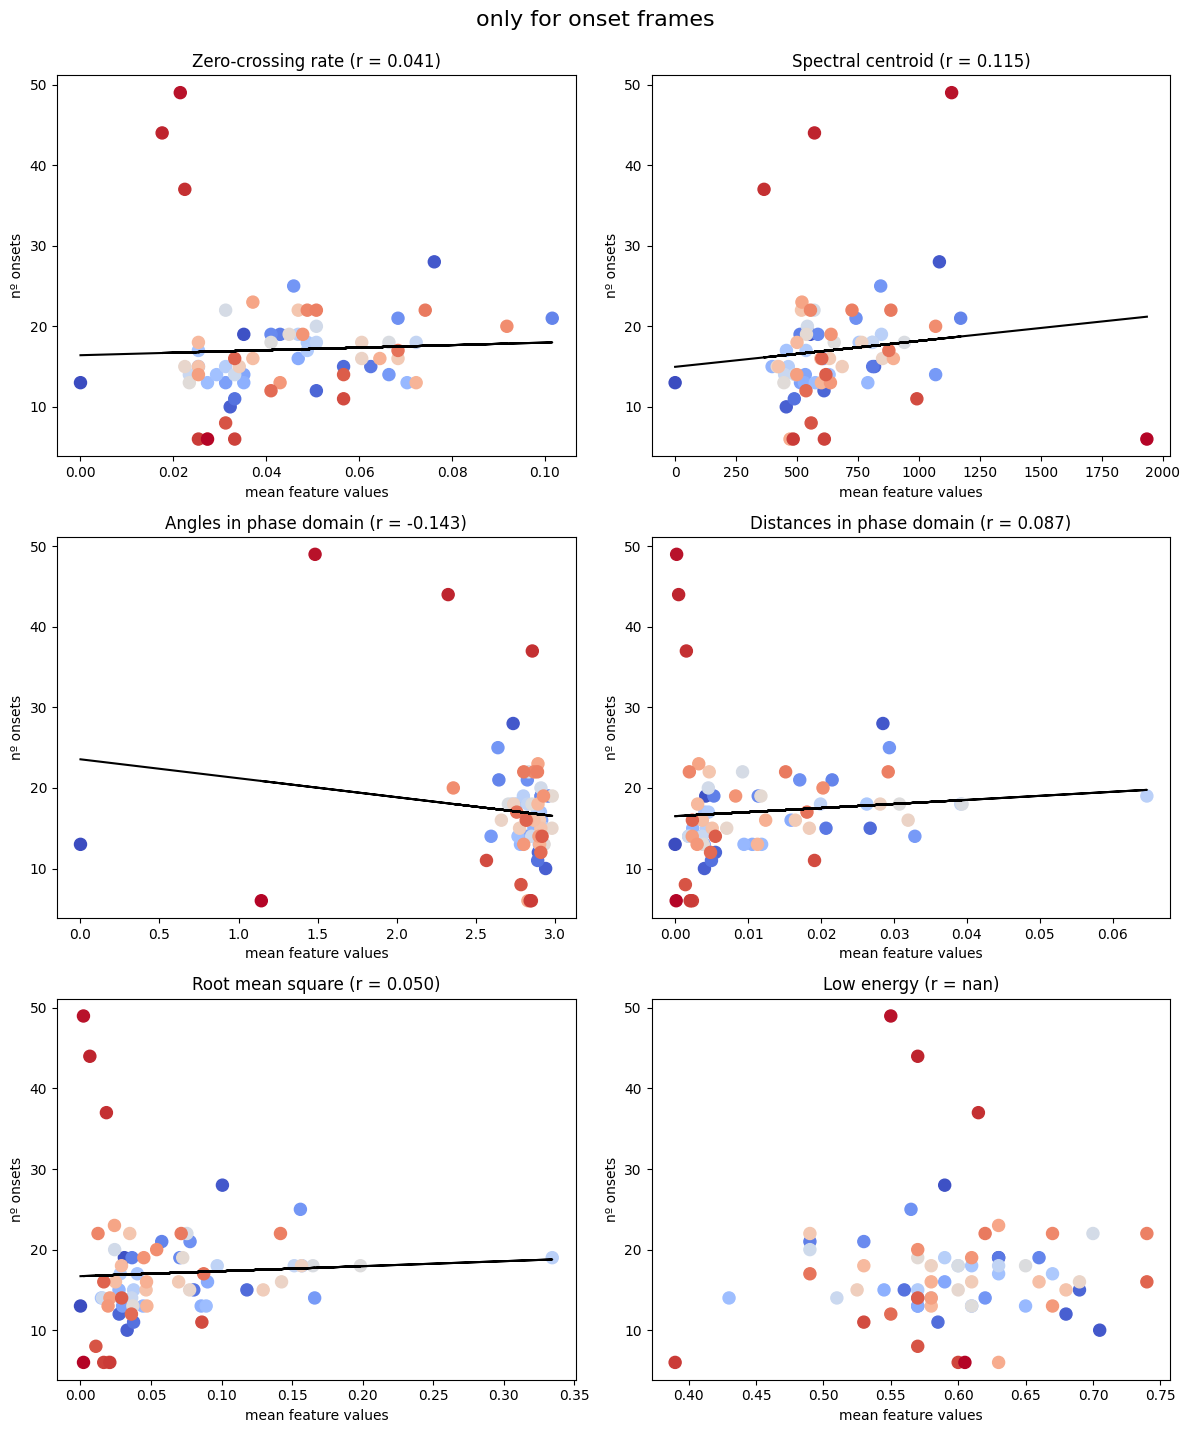

{'Zero-crossing rate': np.float64(0.041150294461338686),
 'Spectral centroid': np.float64(0.11543030809018237),
 'Angles in phase domain': np.float64(-0.14342768532557654),
 'Distances in phase domain': np.float64(0.08672808291615668),
 'Root mean square': np.float64(0.050311949784094756),
 'Low energy': np.float64(nan)}

In [92]:
plot_features(onset_frames_df, title="only for onset frames", regression_line=True)

In [93]:
non_onset_frames_df = (features_df
                       .groupby(np.arange(len(features_df)) // windows_per_chunk)
                       .apply(
    lambda g: g[non_onset_frames_mask[g.index.to_numpy(dtype=int) - 1]].mean(numeric_only=True))
                       .reset_index(drop=True)
                       .reset_index(names='chunk_id'))
print(onset_frames_df)

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.000000          -1.000000                0.000000   
1          1            0.035156         553.804100                2.915847   
2          2            0.076172        1083.786600                2.738030   
3          3            0.032227         455.243195                2.943768   
4          4            0.050781         610.126400                2.897755   
..       ...                 ...                ...                     ...   
64        64            0.025391         483.665860                2.845931   
65        65            0.022461         363.990355                2.859461   
66        66            0.017578         570.974000                2.326865   
67        67            0.021484        1134.034300                1.484570   
68        68            0.027344        1935.413375                1.144395   

    Distances in phase domain  Root mean square  Lo

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


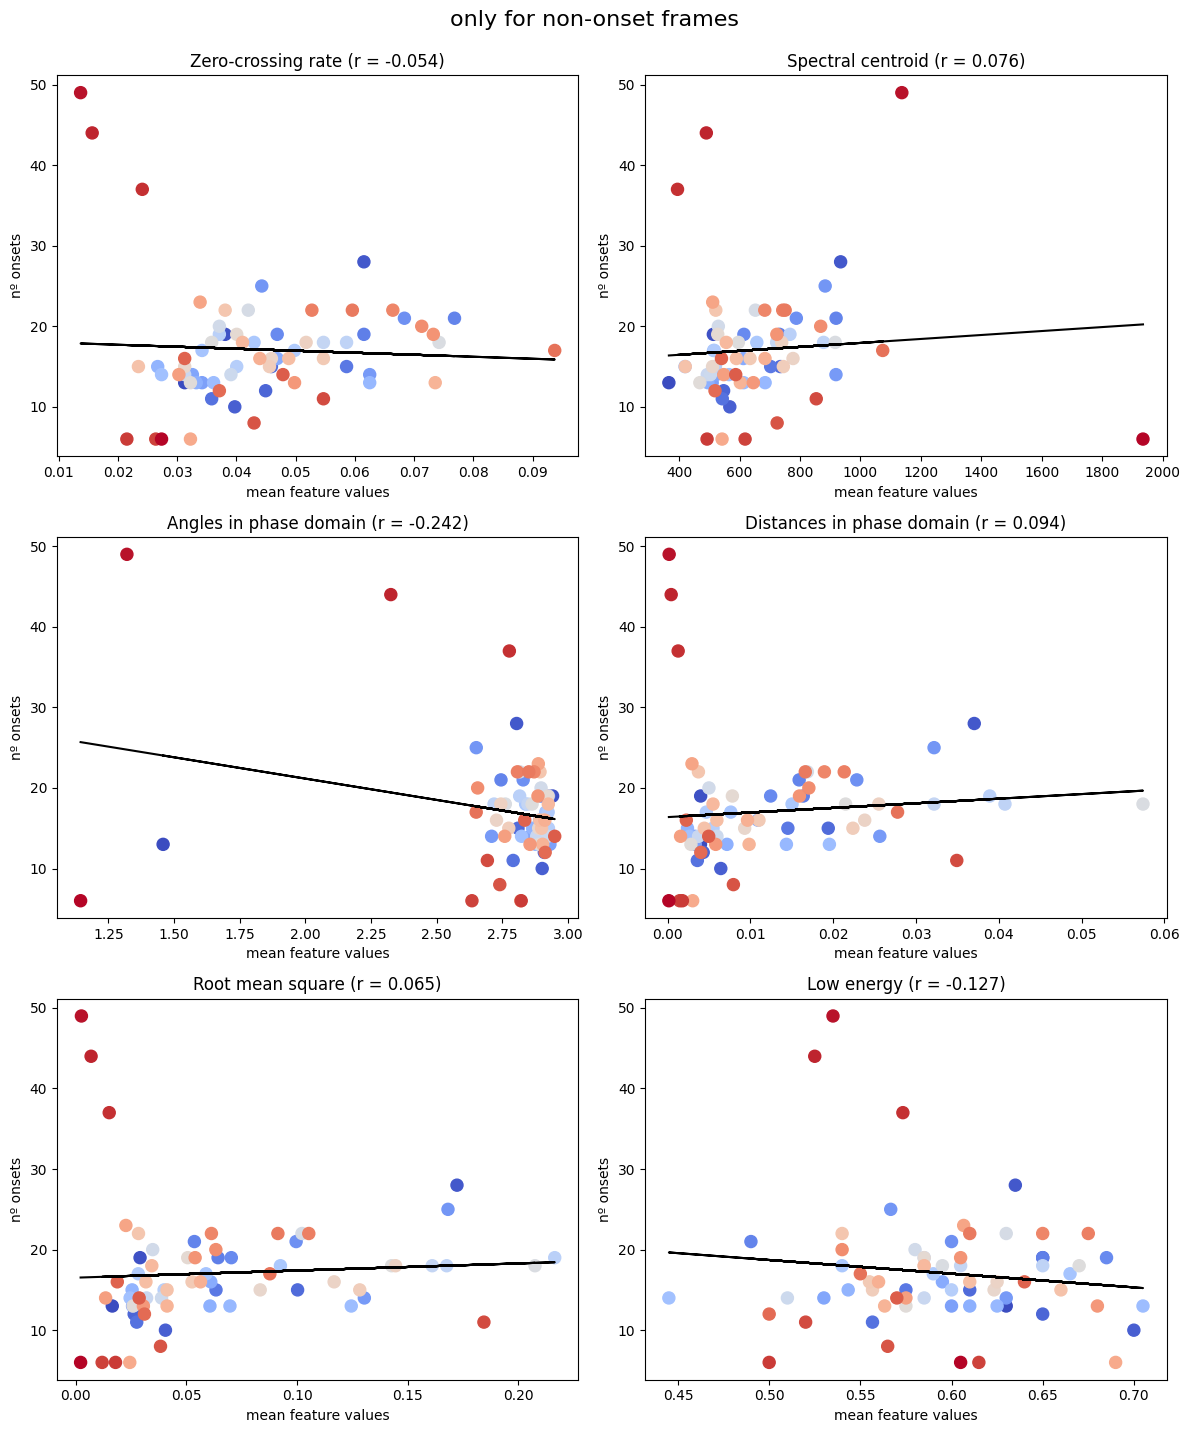

{'Zero-crossing rate': np.float64(-0.05435146235041488),
 'Spectral centroid': np.float64(0.07601934150014002),
 'Angles in phase domain': np.float64(-0.24209129840982968),
 'Distances in phase domain': np.float64(0.09379558660214202),
 'Root mean square': np.float64(0.0648208294623766),
 'Low energy': np.float64(-0.12707290070398594)}

In [94]:
plot_features(non_onset_frames_df, title="only for non-onset frames", regression_line=True)